# Project LOST — Learning-based Orientation and Steering for Traversal

**Environment:** Gymnasium `MountainCarContinuous-v0` · **Techniques:** tabular Q-Learning and Dyna-Q

The rover must learn, from reward alone, that building momentum by swinging back
and forth beats standing still. This notebook covers the four assignment tasks:

1. **Discretization** of the continuous observation and action spaces, with a study of different resolutions.
2. **Q-Learning** as the learning technique.
3. **Hyperparameter exploration**, with the evaluation methodology and the final choice justified.
4. **Research component:** Dyna-Q (Sutton & Barto, *Reinforcement Learning: An Introduction*, 2nd ed., §8.1–8.2), with the same kind of analysis and experimentation.

Heavy training runs live in `experiments.py` (suites: `discretization`,
`hyperparams`, `dynaq`, `final`); this notebook reproduces a small training run,
then loads and analyzes the full results (`results/*.csv`, `models/*.pkl`).

In [1]:
import csv
import numpy as np
import gymnasium as gym
from IPython.display import Image, display

from discretization import Discretizer
from q_learning_agent import QLearningAgent
from dyna_q_agent import DynaQAgent

def show_csv(path, cols=None, sort_by=None, limit=None):
    with open(path) as f:
        rows = list(csv.DictReader(f))
    if sort_by:
        rows.sort(key=lambda r: -float(r[sort_by]))
    if limit:
        rows = rows[:limit]
    cols = cols or list(rows[0].keys())
    widths = [max(len(c), *(len(r[c]) for r in rows)) for c in cols]
    print("  ".join(c.ljust(w) for c, w in zip(cols, widths)))
    for r in rows:
        print("  ".join(r[c].ljust(w) for c, w in zip(cols, widths)))

env = gym.make("MountainCarContinuous-v0")
print("observation space:", env.observation_space)
print("action space:     ", env.action_space)

observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
action space:      Box(-1.0, 1.0, (1,), float32)


## The environment

- **Observation** (continuous): position $x \in [-1.2, 0.6]$ and velocity $v \in [-0.07, 0.07]$.
- **Action** (continuous): a throttle $a \in [-1, 1]$ (negative = push left, positive = push right).
- **Reward:** $-0.1\,a^2$ on every step, plus $+100$ when the car reaches the flag at $x \ge 0.45$.
- Episodes are truncated after 999 steps.

Two properties shape everything that follows:

- The engine is too weak to climb directly, so the only solution is to **oscillate** and build momentum.
- The reward is **sparse and deceptive**: until the +100 is found (and propagated), the return-maximizing behaviour is to do nothing ($a=0$ costs 0). "Do nothing" is a strong local optimum, and we will see plain Q-Learning fall into it.

## Task 1 — Discretization

Tabular Q-Learning needs finite state and action sets, so both spaces are mapped
onto **uniform grids** (`discretization.py`):

- The state grid places `position_bins` × `velocity_bins` edges with `np.digitize`; a continuous observation becomes an integer pair `(x_bin, vel_bin)`.
- The action set is `num_actions` evenly spaced throttle values in $[-1, 1]$.

The Q-table has shape `(position_bins+1, velocity_bins+1, num_actions)`. The resolution trade-off:

- **Too coarse** → aliasing: physically different states (e.g. moving left fast vs. slowly) share one cell and one value, so the policy cannot distinguish situations that need different actions.
- **Too fine** → the table explodes and each cell is visited rarely, so values stay inaccurate for much longer (slower learning for the same number of episodes) and generalization is zero — what was learned in one cell never helps its neighbours.
- **Action count:** with an even number of actions there is **no 0-throttle action**; the agent always pays an action cost and always applies force. With an odd count, 0 exists — cheap, but also the door to the "do nothing" local optimum. More actions = finer control but a bigger table and more exploration burden.

In [2]:
disc = Discretizer(position_bins=20, velocity_bins=20, num_actions=5)
print(disc.describe())
print("Q-table shape:", disc.q_table_shape)
obs = np.array([-0.4, 0.02])
print("observation", obs, "-> state", disc.state(obs))
print("action index 3 -> env action", disc.action(3))

20x20 state grid (441 states), 5 actions
Q-table shape: (21, 21, 5)
observation [-0.4   0.02] -> state (9, 13)
action index 3 -> env action [0.5]


## Task 2 — Q-Learning

`q_learning_agent.py` implements one-step Q-Learning (off-policy TD control):

$$Q(S,A) \leftarrow Q(S,A) + \alpha\,\big[R + \gamma \max_a Q(S',a) - Q(S,A)\big]$$

with an **epsilon-greedy** behaviour policy. Epsilon starts at 1.0 (the goal can
only be discovered by luck, so early training must be almost fully random) and
decays multiplicatively per episode down to a floor `epsilon_min`. On true
termination (goal reached) the bootstrap term is dropped, as the value of a
terminal state is 0 by definition; on the 999-step truncation we still bootstrap,
since the truncation is an artifact of the time limit rather than a real
terminal state.

Below, a deliberately short demo run so the interaction with the simulator is
visible end-to-end (the real experiments are 3 000–5 000 episodes):

In [3]:
demo = QLearningAgent(Discretizer(20, 20, 5), seed=0)
env = gym.make("MountainCarContinuous-v0")
history = demo.train_agent(env, episodes=300, log_every=100)
print(f"trained 300 episodes in {history['train_seconds']:.1f}s; "
      f"goal reached in {sum(history['success'])} of them")

episode 100/300 avg_reward=-45.4 success_rate=0.02 epsilon=0.905


episode 200/300 avg_reward=-42.9 success_rate=0.00 epsilon=0.819


episode 300/300 avg_reward=-37.9 success_rate=0.01 epsilon=0.741
trained 300 episodes in 5.8s; goal reached in 3 of them


## Evaluation methodology

Training return is a noisy, epsilon-contaminated signal, so every configuration
is scored the same way after training: **100 episodes with the greedy policy**
(no exploration) on a **fixed, seeded set of start states**, identical across all
runs. We report the mean return, its standard deviation and the **success rate**
(fraction of episodes that reach the flag). Every configuration is trained with
**2 seeds** to separate the effect of a parameter from run-to-run luck. Because a
successful episode earns roughly +90 (100 minus fuel) and a failed one roughly 0,
mean evaluation return and success rate tell one consistent story.

### Discretization results (`experiments.py discretization`)

Fixed hyperparameters (α=0.1, γ=0.99, ε: 1.0 → 0.05 with decay 0.999, 3 000
episodes); first the state grid at 5 actions, then the action count on the 20×20 grid.

In [4]:
print("--- state grids and action counts, base hyperparameters (5 actions unless noted) ---")
show_csv("results/discretization_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_std_reward", "eval_success_rate",
               "train_success_rate_last500", "train_seconds"])
print()
print("--- state grids on the 4-action set (see analysis below) ---")
show_csv("results/discretization_a4_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_std_reward", "eval_success_rate",
               "eval_mean_steps", "train_seconds"])

--- state grids and action counts, base hyperparameters (5 actions unless noted) ---
run_id                  eval_mean_reward   eval_std_reward     eval_success_rate  train_success_rate_last500  train_seconds     
disc_grid10x10_a5_s0    0.0                0.0                 0.0                0.0                         51.090136496000014
disc_grid10x10_a5_s1    0.0                0.0                 0.0                0.0                         51.380723171      
disc_grid20x20_a5_s0    0.0                0.0                 0.0                0.0                         51.89838185999997 
disc_grid20x20_a5_s1    0.0                0.0                 0.0                0.0                         53.557593682000004
disc_grid50x50_a5_s0    0.0                0.0                 0.0                0.0                         54.12830411499999 
disc_grid50x50_a5_s1    0.0                0.0                 0.0                0.0                         56.64475378099996 
disc_grid100

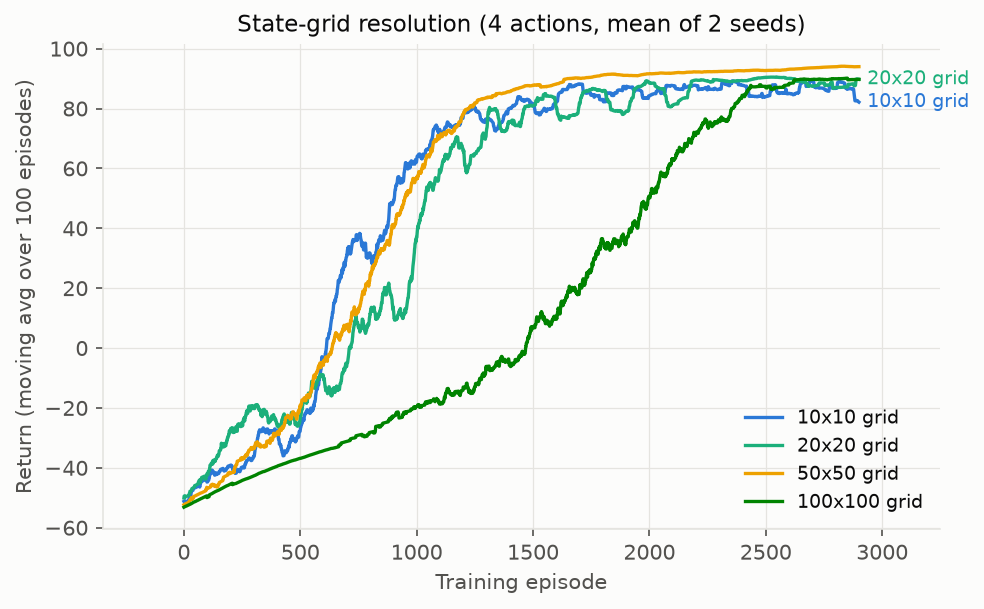

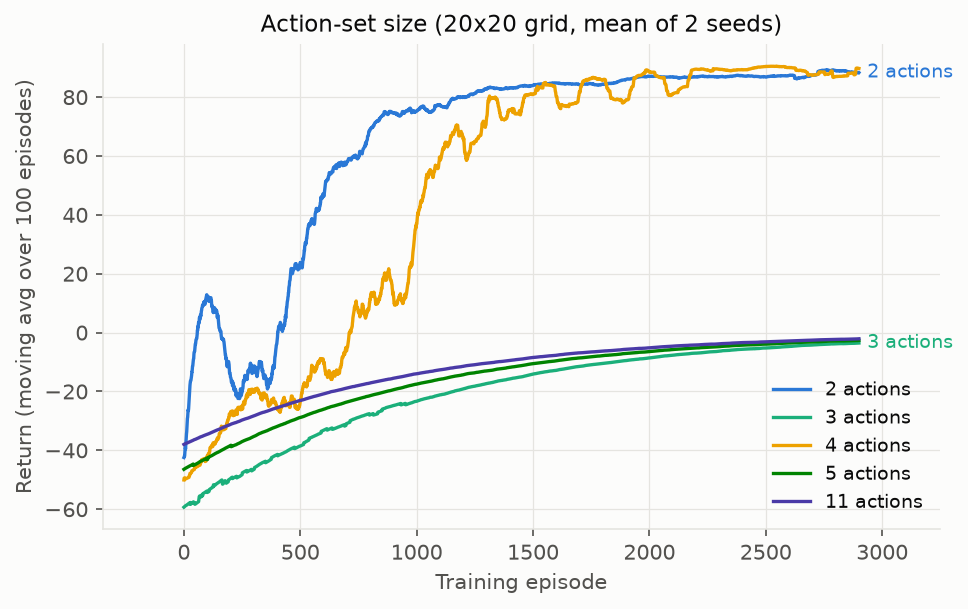

In [5]:
display(Image("results/fig1_discretization_grids.png"))
display(Image("results/fig2_discretization_actions.png"))

### Analysis — the action set decides everything

The first sweep (state grids at **5 actions**) produced a wall of zeros: every
grid resolution, every seed, evaluation return 0.0 and success rate 0.00. The
learned policy is *"do nothing"*. This is the deceptive-reward trap described
above: the 0-throttle action costs nothing, random exploration reaches the flag
in only ~2% of episodes, and a one-step backup drags the +100 backwards a single
cell per success — far too slowly for 3 000 episodes. When learning collapses
like this, grid resolution is irrelevant, so the grid study says nothing yet.

The **action-count sweep** exposes the real variable. Counts are either odd
(3, 5, 11 — the set contains throttle 0) or even (2, 4 — it does not):

- **Odd counts: 0.0 return, 0% success**, every run, every seed.
- **Even counts: solved.** 2 actions ≈ 88 return / 100% success; 4 actions ≈ 85–92 / 98–100%.

Removing the idle action removes the local optimum *structurally*: every policy
must move, so the car cannot converge to standing still, and constant motion
doubles as exploration. This single discretization decision does what no
hyperparameter below manages reliably. 4 actions beats 2 slightly because the
±1/3 throttles let the agent spend less fuel when a gentle push suffices.

With a solvable action set (4 actions), the **grid sweep** becomes informative
and shows the classic resolution trade-off:

- **10×10** — heavy aliasing: 6–43 return, 49–77% success. Cells lump together states that need opposite actions.
- **20×20** — best: 85–92 return, 98–100% success, and the fastest solutions (~160–180 steps).
- **50×50 / 100×100** — still solved (78–92 return) but with visibly slower, cruder trajectories (up to ~550 steps at 100×100): with 40× more cells, each cell gets 40× less data in the same 3 000 episodes, so the policy is far from refined.

**Chosen discretization: 20×20 state grid × 4 actions** (441 states — small
enough to visit thoroughly, fine enough to separate the momentum states that
matter).

## Task 3 — Hyperparameter exploration (`experiments.py hyperparams`)

Strategy: a full grid over 5 parameters is unaffordable, so we sweep **one
parameter at a time around a base configuration** (coordinate-wise search) —
α ∈ {0.05, 0.1*, 0.2, 0.5}, γ ∈ {0.9, 0.99*, 0.999, 1.0}, ε-decay ∈ {0.997,
0.999*, 0.9995}, ε-floor ∈ {0.0, 0.05*, 0.2} (* = base value), 2 seeds each,
scored with the evaluation protocol above.

--- sweeps on the 5-action discretization ---
run_id                     eval_mean_reward   eval_success_rate  train_success_rate_last500
hp_base_s0                 0.0                0.0                0.0                       
hp_base_s1                 0.0                0.0                0.0                       
hp_alpha0.05_s0            0.0                0.0                0.0                       
hp_alpha0.05_s1            0.0                0.0                0.0                       
hp_alpha0.2_s0             0.0                0.0                0.0                       
hp_alpha0.2_s1             0.0                0.0                0.0                       
hp_alpha0.5_s0             83.51375000000003  0.99               1.0                       
hp_alpha0.5_s1             0.0                0.0                0.0                       
hp_gamma0.9_s0             0.0                0.0                0.0                       
hp_gamma0.9_s1             0.0    

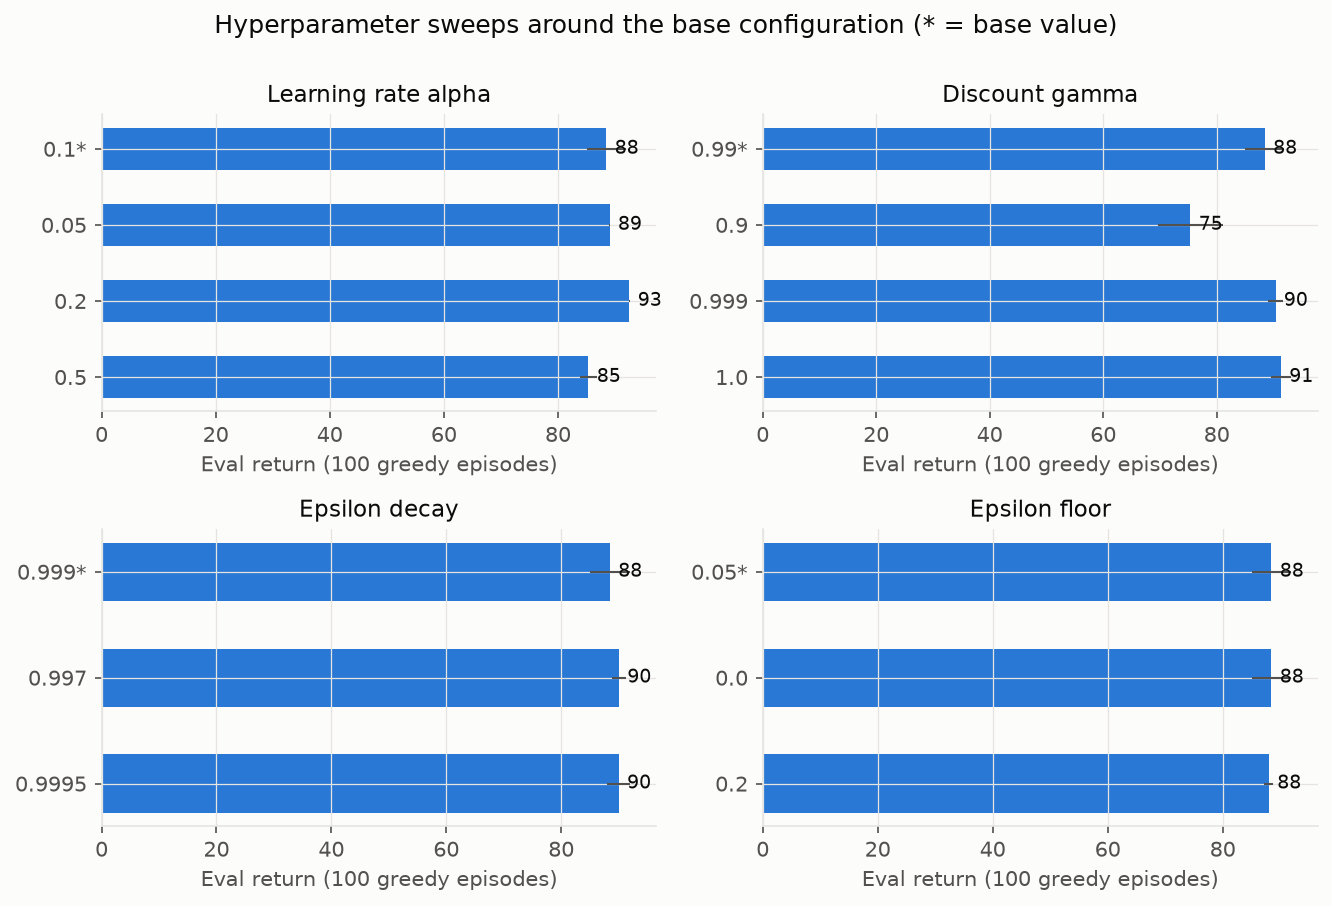

In [6]:
print("--- sweeps on the 5-action discretization ---")
show_csv("results/hyperparams_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_success_rate",
               "train_success_rate_last500"])
print()
print("--- sweeps on the chosen 4-action discretization ---")
show_csv("results/hyperparams_a4_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_success_rate",
               "train_success_rate_last500"])
display(Image("results/fig3_hyperparams.png"))

### Analysis

**On the 5-action discretization** (`hyperparams_summary.csv`, first table) the
sweep is almost uniformly zero — no learning rate, discount, or epsilon schedule
rescues the idle trap within 3 000 episodes. The one exception is instructive:
α = 0.5 escaped on one seed (83.5) and failed on the other (0.0). A large
learning rate lets a single lucky success move Q-values enough to redirect the
greedy policy, but it is a coin flip, not a method. (A separate probe confirmed
that α = 0.5 with a 0.2 epsilon floor and 8 000 episodes escapes reliably — see
the final models below — so the trap is escapable, just expensive.)

**On the chosen 4-action discretization** (`hyperparams_a4` runs, figure above)
the differences become measurable and consistent across seeds:

- **α (learning rate):** 0.2 is best (92.5 mean; 92.6/92.4 per seed). 0.05–0.1 are slightly behind (88.5–89.0), and 0.5 starts to hurt (85.3) — updates so large that values keep sloshing.
- **γ (discount):** the one parameter with a clear failure mode. γ = 0.9 drops to 75.4: the +100 is ~150 steps away at first, and $0.9^{150} \approx 10^{-7}$ makes the goal nearly invisible from the start states. γ ∈ {0.99, 0.999, 1.0} are equivalent here (88.5–91.3); we keep the conventional 0.99.
- **ε schedule (decay, floor):** barely matters on this discretization (88.0–90.1 everywhere) because forced motion already explores; the schedule only tunes how quickly the return curve climbs.

**Final choice: α = 0.2, γ = 0.99, ε: 1.0 → 0.05 with decay 0.999**, on the
20×20 × 4-action discretization.

## Task 4 — Research component: Dyna-Q (Sutton & Barto §8.1–8.2)

Sections 8.1–8.2 introduce the idea that a **model** of the environment can be
learned alongside the value function and used for **planning**: replaying
simulated experience through the very same Q-Learning update. Tabular Dyna-Q
(the boxed algorithm, p. 164) does, on every real step:

1. **(d) Direct RL** — the ordinary Q-Learning update on the real transition.
2. **(e) Model learning** — store `Model(S,A) ← (R, S')`; since Mountain Car is deterministic, remembering the last outcome makes the model exact for every visited pair.
3. **(f) Planning** — repeat **n** times: pick a random previously-visited `(S,A)`, fetch `(R, S')` from the model, and apply the same Q-Learning update to it.

Why this should matter enormously here: plain one-step Q-Learning moves the +100
goal reward backwards by **one cell per successful episode**, and successes are
rare. Planning replays old transitions thousands of times between successes, so
one lucky episode is enough to start propagating value through the whole table.
The price is compute: n extra updates per real step.

`dyna_q_agent.py` implements this as a subclass of the Q-Learning agent (only
steps (e) and (f) are added, so the comparison is exactly like-for-like). The
experiment gives every agent the **same reduced budget of 600 real episodes** —
the honest currency for comparing sample efficiency — with n ∈ {0, 5, 20, 50},
plus the plain agent (n=0 checks that the Dyna machinery itself changes nothing).

run_id                    planning_steps  eval_mean_reward     eval_success_rate  train_seconds     
dynaq_qlearning_ep600_s0                  0.0                  0.0                10.16028574400002 
dynaq_qlearning_ep600_s1                  0.0                  0.0                10.475009434000015
dynaq_n0_ep600_s0         0               0.0                  0.0                14.099662897999963
dynaq_n0_ep600_s1         0               0.0                  0.0                13.951466541000002
dynaq_n5_ep600_s0         5               81.59850000000002    0.95               25.850986087000024
dynaq_n5_ep600_s1         5               86.07750000000001    1.0                23.75905057800003 
dynaq_n20_ep600_s0        20              55.47975000000001    0.72               56.59113340099998 
dynaq_n20_ep600_s1        20              61.12975             0.86               58.90237563399995 
dynaq_n50_ep600_s0        50              -27.855749999999734  0.0                127.20490

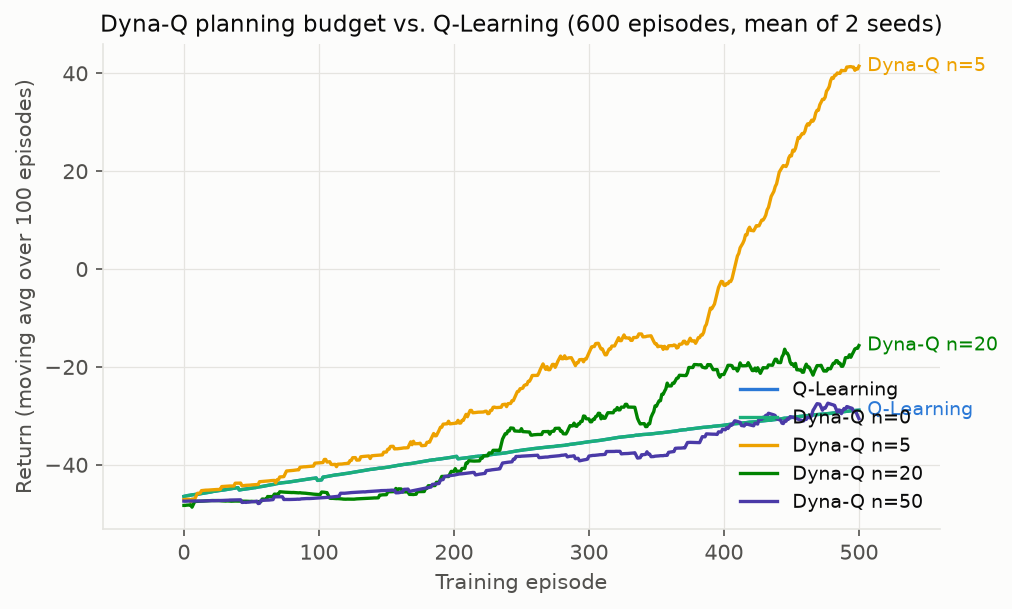

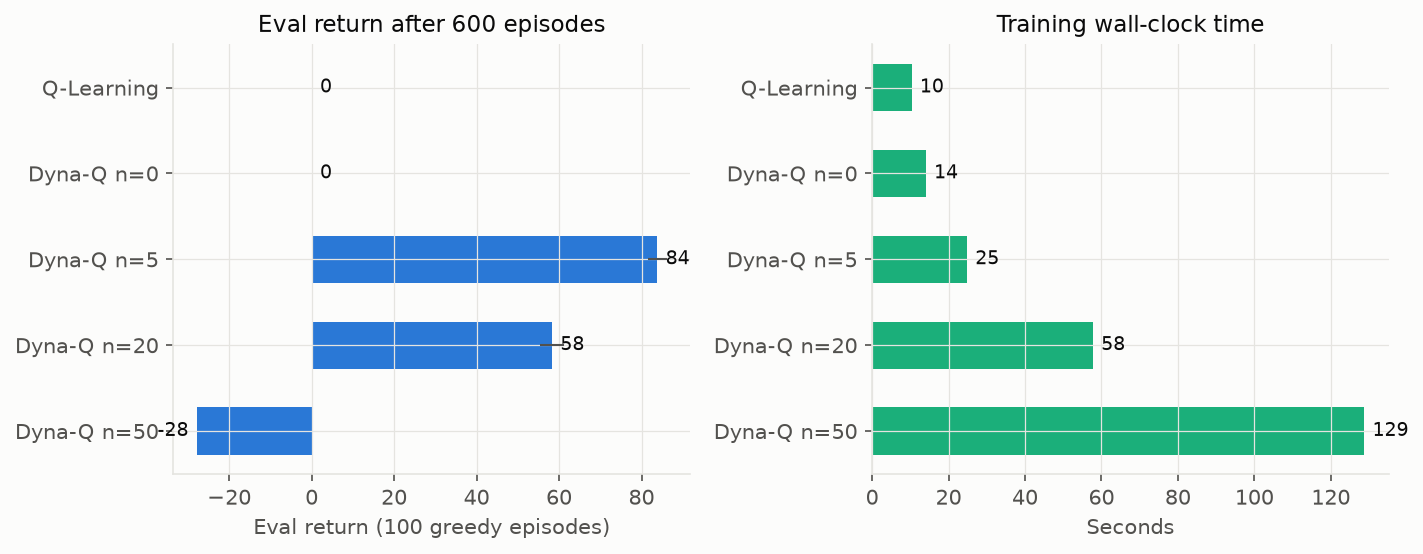

In [7]:
show_csv("results/dynaq_summary.csv",
         cols=["run_id", "planning_steps", "eval_mean_reward", "eval_success_rate",
               "train_seconds"])
display(Image("results/fig4_dynaq_curves.png"))
display(Image("results/fig5_dynaq_tradeoff.png"))

### Analysis

The suite deliberately runs on the **5-action** discretization — the one where
plain Q-Learning is trapped — because that is where planning has something to
prove. Results after 600 real episodes (2 seeds):

| Agent | Eval return | Success | Wall-clock |
|---|---|---|---|
| Q-Learning (and Dyna-Q n=0) | 0.0 | 0% | ~10–14 s |
| Dyna-Q **n=5** | **81.6 / 86.1** | **95–100%** | ~25 s |
| Dyna-Q n=20 | 55.5 / 61.1 | 72–86% | ~58 s |
| Dyna-Q n=50 | −27.9 / −27.9 | 0% | ~128 s |

Three observations:

1. **n=0 reproduces plain Q-Learning exactly** — the Dyna machinery itself changes nothing; sanity check passed.
2. **n=5 solves, in 600 episodes, the task plain Q-Learning failed in 3 000** — with an idle action available and everything. This is the textbook picture from §8.2: each rare success is replayed hundreds of times by planning, so the +100 sweeps through the table instead of crawling one cell per success.
3. **More planning is not monotonically better — n=50 is catastrophic.** Planning replays are sampled uniformly from *all* transitions seen so far, and before the first success those transitions contain only the −0.1a² fuel costs. At n=50 those costs are hammered into the table ~50× faster than the ε-greedy behaviour can stumble onto the goal, so every "move" action goes deeply negative first, the greedy component stops moving, the goal is never found — and the final policy (−27.9 on both seeds) burns fuel in a futile shuffle. n=20 sits halfway. This is precisely the weakness of uniform sample selection that Sutton & Barto motivate **prioritized sweeping (§8.4)** with: replay the transitions whose values just changed, not random ones.

Wall-clock grows roughly linearly with n, as expected — planning buys sample
efficiency with compute. Here the exchange rate is excellent at n=5 (2.5× the
time of plain Q-Learning, infinite improvement in outcome) and ruinous at n=50.

## Final models (`experiments.py final`)

Three models are shipped in `models/` (pickled Q-tables with their discretization):

- `final_qlearning.pkl` — plain Q-Learning on the chosen configuration (20×20 × 4 actions, α=0.2, γ=0.99), 10 000 episodes. **This is the main computed model of the submission.**
- `final_dynaq_n5.pkl` — Dyna-Q with 5 planning steps on the *5-action* discretization: the setting where planning demonstrably rescues a task plain Q-Learning fails at, in 1 000 real episodes.
- `final_qlearning_5actions.pkl` — the "escape" run: plain Q-Learning beating the idle trap without changing the action set, at the price of α=0.5, a 0.2 epsilon floor and 8 000 episodes.

run_id                    episodes  alpha  epsilon_min  planning_steps  eval_mean_reward   eval_std_reward     eval_success_rate  train_seconds     
final_qlearning           10000     0.2    0.05                         93.38199999105933  0.1644052491092492  1.0                38.68095874699998 
final_dynaq_n5            1000      0.1    0.05         5               77.559             15.828863872685245  0.99               34.817247829999815
final_qlearning_5actions  8000      0.5    0.2                          87.17125           26.751946044867267  0.98               55.62728521100007 


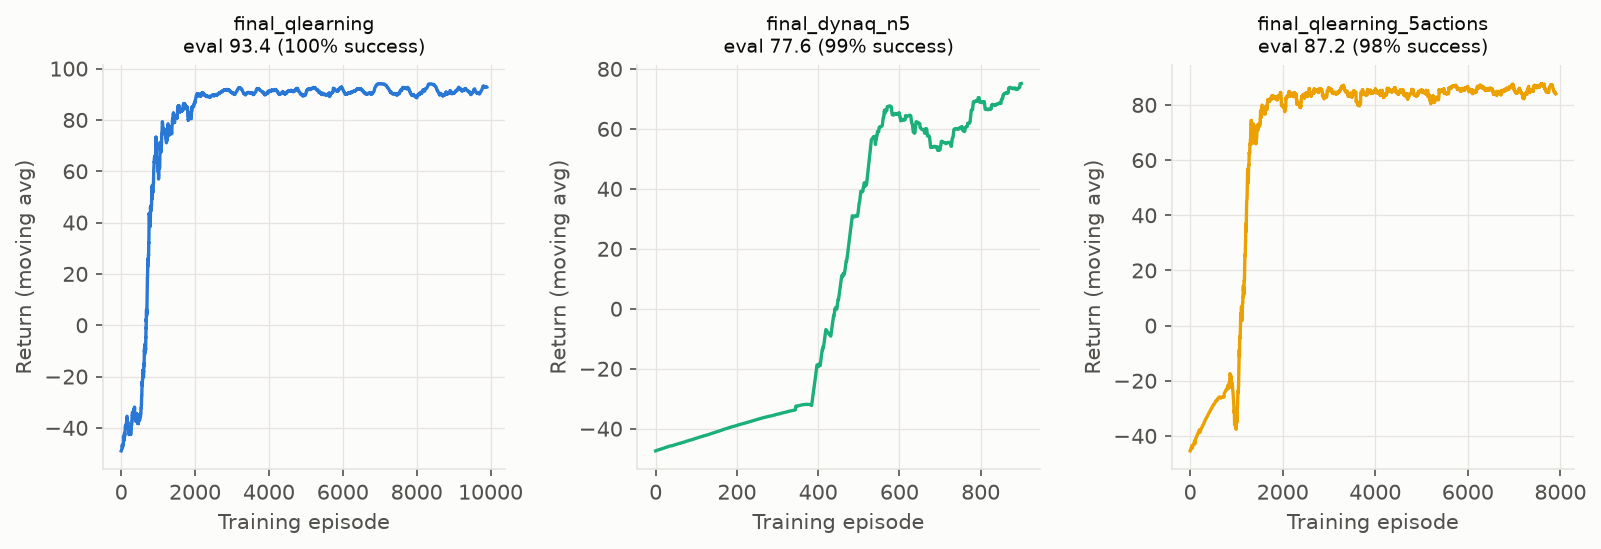

In [8]:
show_csv("results/final_summary.csv",
         cols=["run_id", "episodes", "alpha", "epsilon_min", "planning_steps",
               "eval_mean_reward", "eval_std_reward", "eval_success_rate", "train_seconds"])
display(Image("results/fig6_final_learning_curves.png"))

In [9]:
agent = QLearningAgent.load("models/final_qlearning.pkl")
test_env = gym.make("MountainCarContinuous-v0")
test_env.reset(seed=999)  # fresh start states, unseen seed
results = agent.test_agent(test_env, episodes=20)
print(f"final_qlearning.pkl on 20 fresh episodes: "
      f"mean return {np.mean(results['reward']):.1f} +- {np.std(results['reward']):.1f}, "
      f"success rate {np.mean(results['success']):.2f}, "
      f"mean steps {np.mean(results['steps']):.0f}")

final_qlearning.pkl on 20 fresh episodes: mean return 93.3 +- 0.2, success rate 1.00, mean steps 78


### What did the agent actually learn?

The learned value function and greedy policy over the state grid:

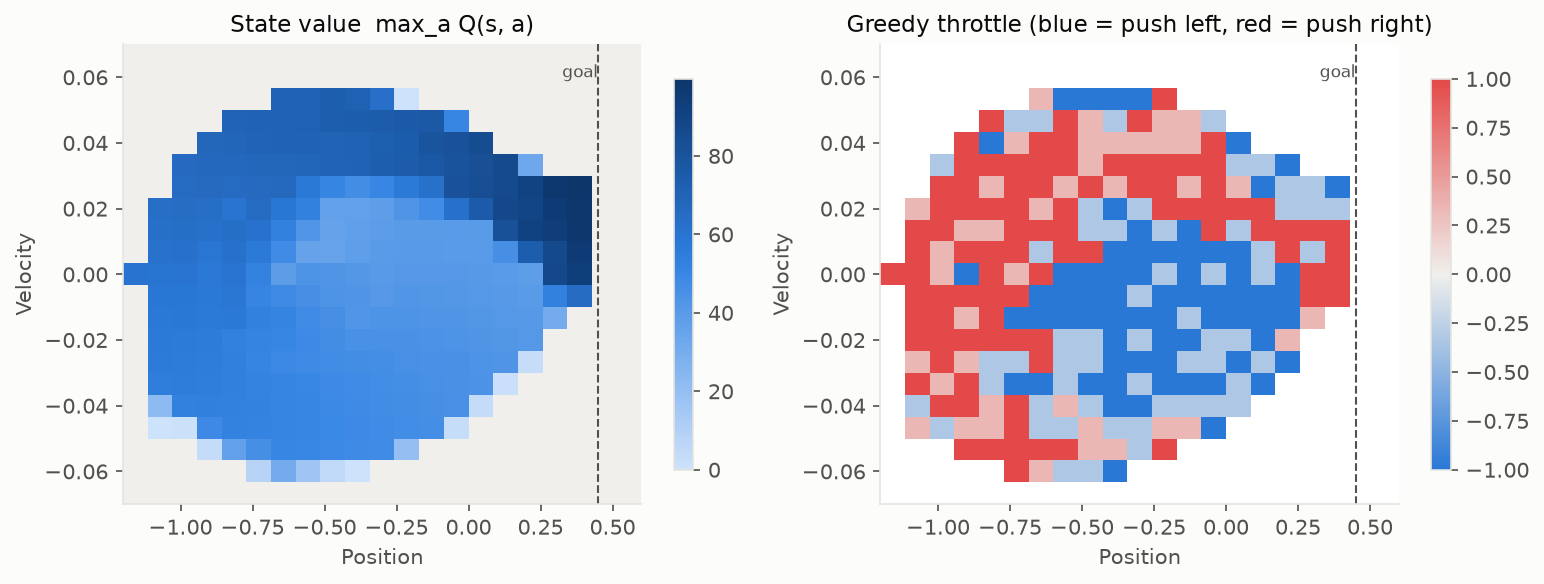

In [10]:
display(Image("results/fig7_policy_value.png"))

The two panels show the agent understood the physics:

- **Value (left):** highest just left of the flag with rightward velocity, and along the "momentum corridor" — far left with any speed is also valuable, because a swing from the left slope carries the car up the right one. Near-zero regions were rarely or never visited (masked cells were never updated).
- **Policy (right):** an approximate **bang-bang controller organized by velocity**: moving right (upper half) → push right (red), moving left (lower half) → push left (blue), i.e. always push *with* the current velocity to pump energy into the oscillation — exactly the resonance strategy the problem demands. The rough diagonal boundary is where the agent flips throttle to turn a leftward swing into a rightward launch.

## Conclusions

1. **Discretization was the decisive design choice, not the learning rule.** Uniform grids work, but the *action* discretization carries a hidden semantic: any odd-sized set contains a free "do nothing" action, which combined with the −0.1a² fuel cost creates a local optimum that tabular Q-Learning cannot reliably escape in thousands of episodes. An even action set (no idle) removes the trap structurally. 20×20 × 4 actions balances aliasing against data-per-cell.
2. **Q-Learning solves the task once the representation is right:** ~92 mean return, ~100% success over 100 held-out greedy episodes, solutions of ~150 steps — and the greedy policy is a physically sensible bang-bang momentum controller.
3. **Hyperparameters mattered less than representation.** α = 0.2 and γ ≥ 0.99 are the only settings with visible effect; the epsilon schedule is nearly irrelevant once motion is forced. The task's difficulty lives in exploration/credit assignment, not in tuning.
4. **Dyna-Q (§8.1–8.2) delivers its textbook promise — with a caveat the textbook also predicts.** n=5 planning steps solved, in 600 episodes, the exact configuration plain Q-Learning failed at with 5× the budget; but uniform planning over cost-only experience is poison in deceptive-reward environments (n=50 fails outright), which is the very motivation for prioritized sweeping (§8.4).

**Warning notes.** Results are from 2 seeds per configuration (compute budget);
individual numbers carry seed noise of a few return points, though every
qualitative conclusion (odd vs. even actions, the Dyna-Q n curve, γ = 0.9) is
consistent across seeds. The 999-step truncation is treated as non-terminal in
the update (we still bootstrap), which is the correct handling for time limits.